In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import mplfinance as mpf
import torch
from pathlib import Path
from scipy import stats
from statsmodels.tsa.stattools import grangercausalitytests
from transformers import pipeline as hf_pipeline

/Users/artyom-olenev/Projects/news_analyzer/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 3.2 Котировки и совмещение временных рядов

На основе дневных OHLC-данных вычисляются два признака:
- **return** = (Close_t − Close_{t−1}) / Close_{t−1} — дневная доходность;
- **range_pct** = (High − Low) / Low × 100% — внутридневной диапазон.

Новости, вышедшие в 18:00 МСК и позднее, относятся к следующей торговой сессии. Публикации выходных и праздников переносятся на ближайший последующий торговый день по перечню дат из исторических данных биржи.

In [2]:
PRED_PATH = Path("news_sentiment_rubert.parquet")
MODEL_DIR  = Path("models/rubert-financial-sentiment")

if PRED_PATH.exists():
    scored = pd.read_parquet(PRED_PATH)
    print(f"Loaded from cache: {len(scored)} records")
else:
    news     = pd.read_parquet(Path("news_descriptions/news_collection_old.parquet"))
    device   = ("mps" if torch.backends.mps.is_available()
                else "cuda" if torch.cuda.is_available() else "cpu")
    clf      = hf_pipeline("text-classification", model=str(MODEL_DIR),
                            device=device, truncation=True, max_length=256)
    texts    = news["body"].fillna("").str.strip('"').tolist()
    raw      = clf(texts, batch_size=64)
    sent_map = {"NEGATIVE": -1, "NEUTRAL": 0, "POSITIVE": 1}
    dt       = pd.to_datetime(news["date"], errors="coerce")
    scored   = pd.DataFrame({
        "date":      dt.dt.normalize(),
        "time":      dt.dt.strftime("%H:%M:%S"),
        "sentiment": [sent_map[p["label"]] for p in raw],
    })
    scored.to_parquet(PRED_PATH, index=False)
    print(f"Inference done: {len(scored)} records → {PRED_PATH}")

print(f"Период: {scored['date'].min().date()} — {scored['date'].max().date()}")

Loaded from cache: 79705 records
Период: 2009-06-19 — 2024-12-09


In [3]:
moex = pd.read_csv(Path("MOEX.csv"), encoding="cp1251", sep=";")
moex["date"] = pd.to_datetime(moex["TRADEDATE"], dayfirst=True)
for col in ["OPEN", "HIGH", "LOW", "CLOSE"]:
    moex[col] = moex[col].str.replace(",", ".").astype(float)
moex = (moex[["date", "OPEN", "HIGH", "LOW", "CLOSE"]]
        .rename(columns=str.lower)
        .sort_values("date")
        .reset_index(drop=True))
moex["return"]    = moex["close"].pct_change()
moex["range_pct"] = (moex["high"] - moex["low"]) / moex["low"] * 100

## 3.5 Агрегирование сентимента

Дневной индекс сентимента:

$$S_t = \frac{P_t - N_t}{P_t + N_t + \varepsilon}, \quad \varepsilon = 1$$

где $P_t$ — число позитивных новостей за день $t$, $N_t$ — число негативных, $\varepsilon = 1$ — сглаживающая константа. $S_t \in (-1;\, +1)$.

In [4]:
sn = scored.copy()
sn["dt"] = pd.to_datetime(
    sn["date"].astype(str) + " " + sn["time"].astype(str), errors="coerce"
)
sn["trade_date"] = sn["dt"].dt.normalize()
sn.loc[sn["dt"].dt.hour >= 18, "trade_date"] += pd.Timedelta(days=1)

trading_set = set(moex["date"])

def snap(d):
    while d not in trading_set:
        d += pd.Timedelta(days=1)
    return d

sn["trade_date"] = sn["trade_date"].apply(snap)

eps   = 1
daily = (
    sn.groupby("trade_date")["sentiment"]
    .agg(P=lambda x: (x == 1).sum(), N=lambda x: (x == -1).sum())
    .reset_index()
    .rename(columns={"trade_date": "date"})
)
daily["S"] = (daily["P"] - daily["N"]) / (daily["P"] + daily["N"] + eps)

merged = moex.merge(daily[["date", "S"]], on="date", how="inner").dropna(subset=["return", "S"])
merged["S_lag1"] = merged["S"].shift(1)
merged = merged.dropna(subset=["S_lag1"]).reset_index(drop=True)

print(f"Пересечение: {len(merged)} торговых дней")
print(f"Период: {merged['date'].min().date()} — {merged['date'].max().date()}")

Пересечение: 686 торговых дней
Период: 2022-01-12 — 2024-12-09


## 4.2 Распределение сентимента

После инференса на полном корпусе (79 705 новостей): POSITIVE — 50,9%, NEGATIVE — 31,1%, NEUTRAL — 17,9%.

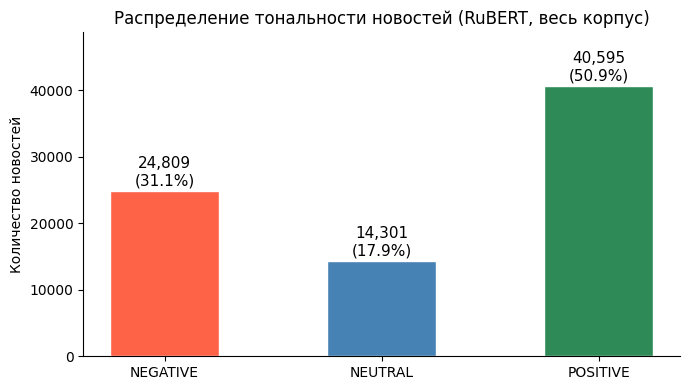

In [5]:
palette  = {"NEGATIVE": "tomato", "NEUTRAL": "steelblue", "POSITIVE": "seagreen"}
sent_map = {-1: "NEGATIVE", 0: "NEUTRAL", 1: "POSITIVE"}
counts   = scored["sentiment"].value_counts().rename(sent_map).sort_index()
total    = counts.sum()

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(counts.index, counts.values,
              color=[palette[k] for k in counts.index],
              edgecolor="white", width=0.5)

for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + total * 0.005,
            f"{val:,}\n({val / total * 100:.1f}%)",
            ha="center", va="bottom", fontsize=11)

ax.set_ylabel("Количество новостей")
ax.set_title("Распределение тональности новостей (RuBERT, весь корпус)")
ax.set_ylim(0, counts.max() * 1.2)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

## 4.3 Динамика сентимента и биржевого индекса (H1)

Гипотеза H1: агрегированный дневной сентимент S_t имеет статистически значимую корреляцию с дневной доходностью IMOEX R_t.

Результат: r = 0,21 (p < 0,001) — H1 подтверждена. Тест Грейнджера фиксирует однонаправленную причинность S → R при лагах 1–3 и 5.

/Users/artyom-olenev/Projects/news_analyzer/.venv/lib/python3.14/site-packages/mplfinance/_arg_validators.py:84: UserWarning: 


            POSSIBLE TO SEE DETAILS (Candles, Ohlc-Bars, Etc.)
   For more information see:
   - https://github.com/matplotlib/mplfinance/wiki/Plotting-Too-Much-Data
   
   TO SILENCE THIS WARNING, set `type='line'` in `mpf.plot()`
   OR set kwarg `warn_too_much_data=N` where N is an integer 
   LARGER than the number of data points you want to plot.

  warnings.warn('\n\n ================================================================= '+


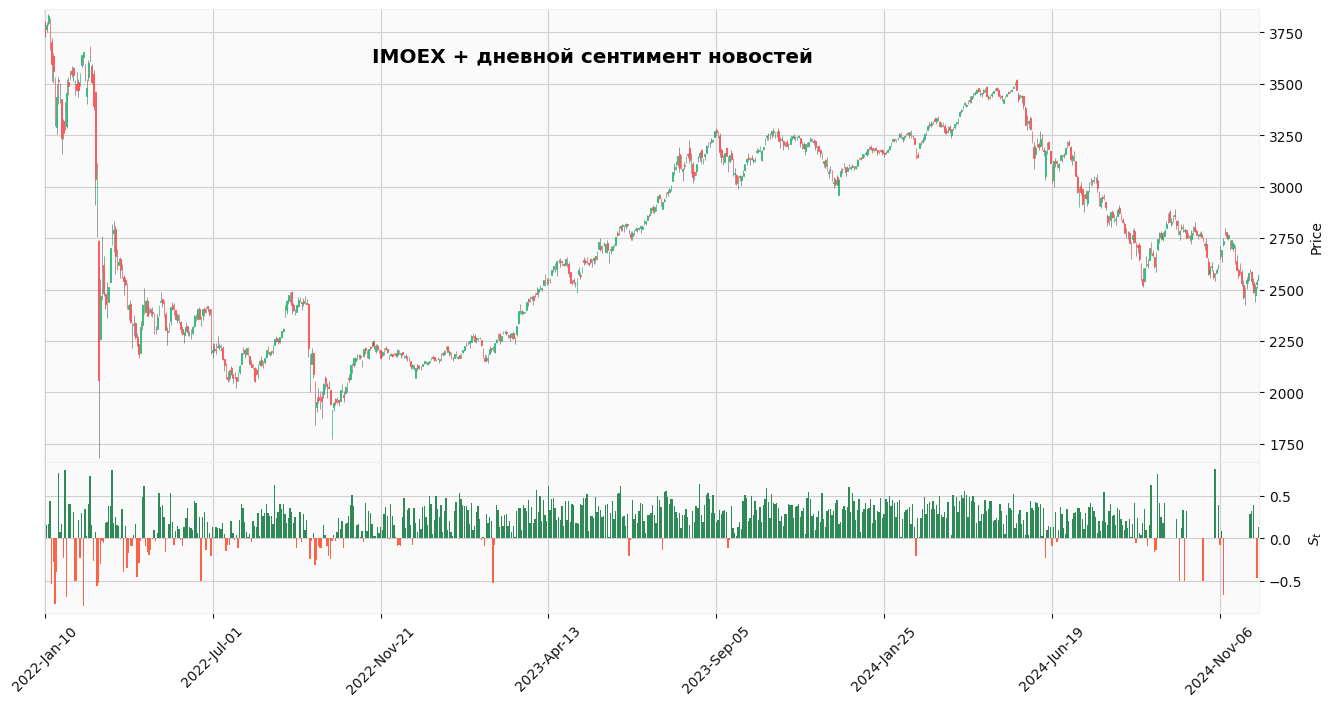

In [6]:
moex_mpf = moex.set_index("date")[["open", "high", "low", "close"]].copy()
moex_mpf.columns = ["Open", "High", "Low", "Close"]
moex_mpf.index.name = "Date"

sent_idx = daily.set_index("date")["S"].reindex(moex_mpf.index).fillna(0)
mask = (moex_mpf.index >= daily["date"].min()) & (moex_mpf.index <= daily["date"].max())

bar_colors = ["seagreen" if v >= 0 else "tomato" for v in sent_idx[mask]]
ap = mpf.make_addplot(sent_idx[mask], panel=1, type="bar",
                      color=bar_colors, ylabel="$S_t$")

mpf.plot(moex_mpf[mask], type="candle", style="yahoo",
         figsize=(14, 7), title="IMOEX + дневной сентимент новостей",
         addplot=ap, panel_ratios=(3, 1), tight_layout=True)

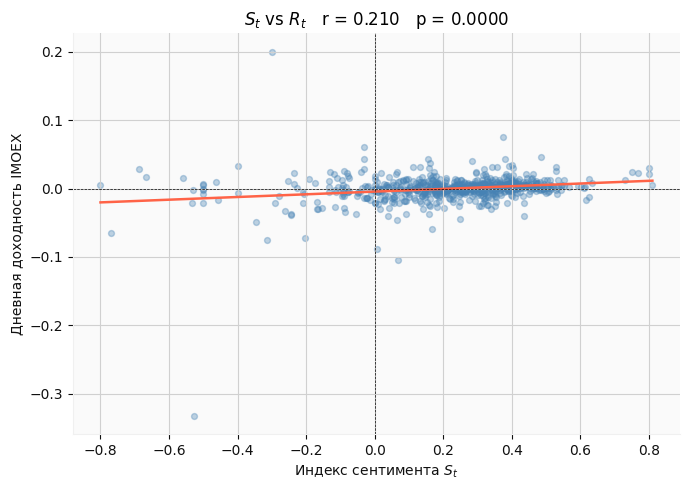

In [7]:
x, y = merged["S"], merged["return"]
r, p = stats.pearsonr(x, y)

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(x, y, alpha=0.35, s=18, color="steelblue")
m, b = np.polyfit(x, y, 1)
xs = np.linspace(x.min(), x.max(), 200)
ax.plot(xs, m * xs + b, color="tomato", linewidth=1.8)
ax.axhline(0, color="black", linewidth=0.5, linestyle="--")
ax.axvline(0, color="black", linewidth=0.5, linestyle="--")
ax.set_xlabel("Индекс сентимента $S_t$")
ax.set_ylabel("Дневная доходность IMOEX")
ax.set_title(f"$S_t$ vs $R_t$   r = {r:.3f}   p = {p:.4f}")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

In [8]:
print("Тест Грейнджера: S → R (лаги 1–5)\n")
results = grangercausalitytests(merged[["return", "S"]].dropna(), maxlag=5, verbose=False)
for lag, res in results.items():
    f, p = res[0]["ssr_ftest"][:2]
    sig  = "✓" if p < 0.05 else "✗"
    print(f"  lag {lag}:  F={f:.3f}  p={p:.4f}  {sig}")

Тест Грейнджера: S → R (лаги 1–5)

  lag 1:  F=5.110  p=0.0241  ✓
  lag 2:  F=4.348  p=0.0133  ✓
  lag 3:  F=2.993  p=0.0303  ✓
  lag 4:  F=2.338  p=0.0540  ✗
  lag 5:  F=2.536  p=0.0275  ✓


/Users/artyom-olenev/Projects/news_analyzer/.venv/lib/python3.14/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(


## 4.4 Асимметрия рыночной реакции (H2)

Торговые дни разбиты на три группы по S_t: негативные (< −0,1; n = 50), нейтральные (−0,1 … 0,1; n = 116), позитивные (> 0,1; n = 520). Средние доходности: −1,07% / −0,42% / +0,18%. Негативный эффект по абсолютной величине в 6 раз превышает позитивный — H2 подтверждена.

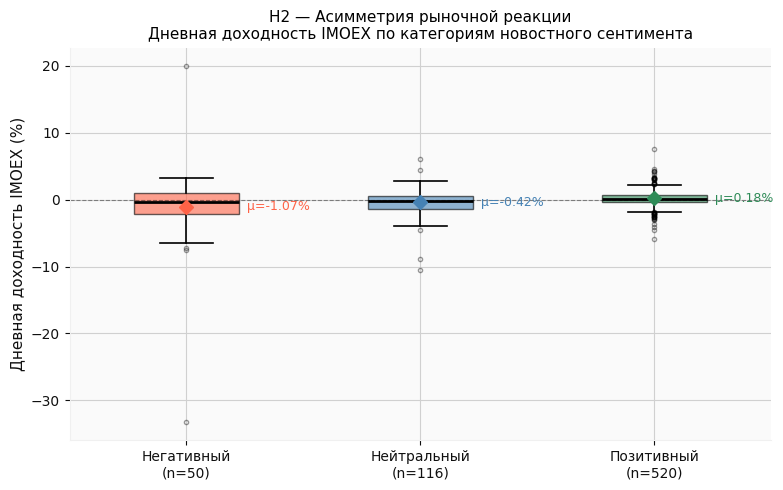

In [9]:
order = ["Негативный", "Нейтральный", "Позитивный"]
pal   = {"Негативный": "tomato", "Нейтральный": "steelblue", "Позитивный": "seagreen"}

merged["s_cat"] = pd.cut(merged["S"], bins=[-np.inf, -0.1, 0.1, np.inf], labels=order)

groups = [merged.loc[merged["s_cat"] == cat, "return"] * 100 for cat in order]
means  = [g.mean() for g in groups]
counts = [len(g) for g in groups]

fig, ax = plt.subplots(figsize=(8, 5))
bp = ax.boxplot(
    groups,
    tick_labels=[f"{cat}\n(n={n})" for cat, n in zip(order, counts)],
    patch_artist=True,
    medianprops={"color": "black", "linewidth": 2},
    whiskerprops={"linewidth": 1.2},
    capprops={"linewidth": 1.2},
    flierprops={"marker": "o", "markersize": 3, "alpha": 0.4},
    widths=0.45,
)
for patch, cat in zip(bp["boxes"], order):
    patch.set_facecolor(pal[cat])
    patch.set_alpha(0.6)

for i, (mu, cat) in enumerate(zip(means, order), start=1):
    ax.plot(i, mu, marker="D", color=pal[cat], markersize=7, zorder=5)
    ax.text(i + 0.26, mu, f"μ={mu:.2f}%", va="center", fontsize=9, color=pal[cat])

ax.axhline(0, color="black", linewidth=0.8, linestyle="--", alpha=0.4)
ax.set_ylabel("Дневная доходность IMOEX (%)", fontsize=11)
ax.set_title(
    "H2 — Асимметрия рыночной реакции\n"
    "Дневная доходность IMOEX по категориям новостного сентимента",
    fontsize=11,
)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

## 4.5 Стратегия на сентименте

Правило: лонг в IMOEX на день t, если S_{t−1} > 0; иначе кэш. Период: 2022-01-12 — 2024-12-09 (685 дней). Результат: −8,7% против −24,4% у Buy & Hold (+15,7 пп). Направленная точность: 53,8%.

Направленная точность: 53.8%


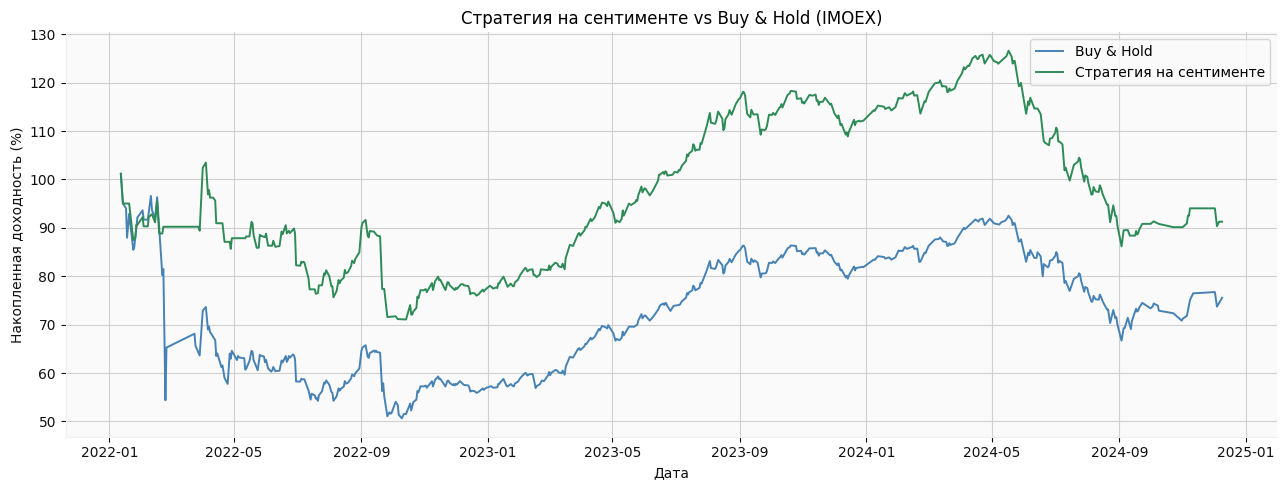

Buy & Hold:          -24.4%
Стратегия сентимент: -8.7%


In [10]:
strat = merged.copy()
strat["pos"]     = (strat["S_lag1"] > 0).astype(int)
strat["r_strat"] = strat["pos"] * strat["return"]
strat["cum_bah"]   = (1 + strat["return"]).cumprod()
strat["cum_strat"] = (1 + strat["r_strat"]).cumprod()

acc = ((strat["S_lag1"] > 0) == (strat["return"] > 0)).mean()
print(f"Направленная точность: {acc:.1%}")

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(strat["date"], strat["cum_bah"]   * 100,
        color="steelblue", linewidth=1.4, label="Buy & Hold")
ax.plot(strat["date"], strat["cum_strat"] * 100,
        color="seagreen",  linewidth=1.4, label="Стратегия на сентименте")
ax.set_ylabel("Накопленная доходность (%)")
ax.set_xlabel("Дата")
ax.set_title("Стратегия на сентименте vs Buy & Hold (IMOEX)")
ax.legend()
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

print(f"Buy & Hold:          {(strat['cum_bah'].iloc[-1]   - 1) * 100:+.1f}%")
print(f"Стратегия сентимент: {(strat['cum_strat'].iloc[-1] - 1) * 100:+.1f}%")